# EEG During mental arithmetic

This data has been extracted from https://physionet.org/content/eegmat/1.0.0/
Original publication: https://physionet.org/content/eegmat/1.0.0/

Other EEG data can be found here: https://openneuro.org/

We will use this dataset to showcase the MESA pipeline, utilizing PCA, MSPC and ASCA as the analysis tools

In [58]:
import mne
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Initial raw data exploration

In [59]:
subject_info = pd.read_csv("../data/EEG/subject-info.csv")
subject_info.head() # ---> Get classes for MEDA visualization from here.

,Subject,Age,Gender,Recording year,Number of subtractions,Count quality
0,Subject00,21,F,2011,9.70,0
1,Subject01,18,F,2011,29.35,1
2,Subject02,19,F,2012,12.88,1
3,Subject03,17,F,2010,31.00,1
4,Subject04,17,F,2010,8.60,0


In [60]:
subject_ids             = subject_info["Subject"].to_numpy(dtype=str)
subject_ages            = subject_info["Age"].to_numpy(dtype=int)
subject_genders         = subject_info["Gender"].to_numpy(dtype=str)
subject_rec_years       = subject_info["Recording year"].to_numpy(dtype=int)
subject_n_subtractions  = subject_info["Number of subtractions"].to_numpy(dtype=float)
subject_quality         = subject_info["Count quality"].to_numpy(dtype=int)
operations = [1, 2]
operation_labels = ["Baseline", "Arithmetic"]

In [61]:
subject_id = subject_ids[10]
operation = operations[0]
file = f"../data/EEG/{subject_id}_{operation}.edf"
data = mne.io.read_raw_edf(file)
raw_data = data.get_data()[:, 0:]
info = data.info
channels = data.ch_names

Extracting EDF parameters from ../data/EEG/Subject10_1.edf...
Setting channel info structure...
Creating raw.info structure...


In [62]:
print(f"There are:\n - {len(subject_ids)} subjects. \n - {len(channels)} channels. \nSampling rate: 500.0Hz")

There are:
 - 36 subjects. 
 - 21 channels. 
Sampling rate: 500.0Hz


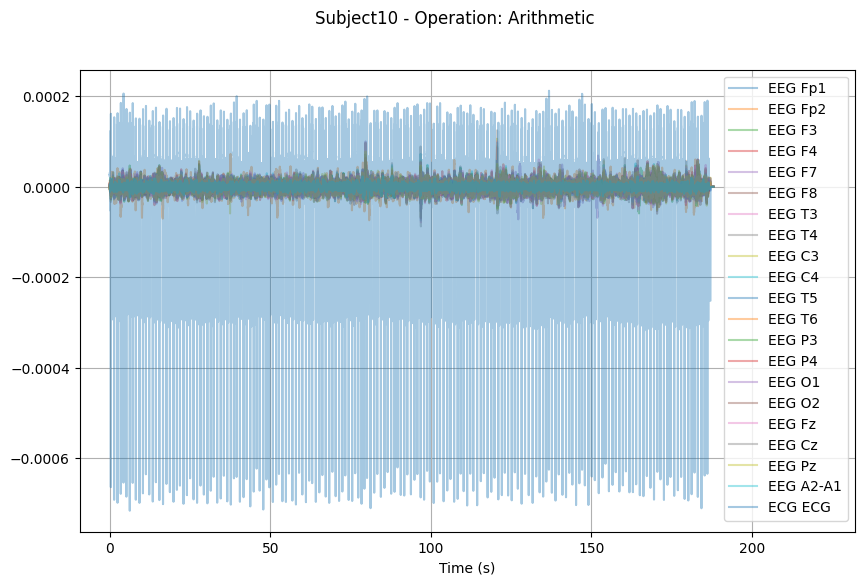

In [63]:

test_signal = raw_data[:, :].T
time = np.linspace(0, test_signal.shape[0]/500, test_signal.shape[0])
fig, ax = plt.subplots(1,1, figsize=(10,6))
fig.suptitle(f"{subject_id} - Operation: {operation_labels[operation]}")
ax.plot(time, test_signal, label=channels, alpha=0.4)
ax.grid(True)
ax.legend()
ax.set_xlabel("Time (s)");
xlim = ax.get_xlim()
ax.set_xlim(xlim[0], xlim[1]*1.175);
# ax.set_xlim(182, 195);


## MESA: Build tensor

Tensor: individuo $\times$ channel $\times$ operación $\times$ tiempo $\times$ frecuencias 

Dimensiones: 36 $\times$ 21 $\times$  2 $\times$ T $\times$ F


In [64]:
import mne
import numpy as np
import msa.feature_extraction.features as features

### STFT Parameters

In [65]:
# STFT parameters
sr = 500.0 # Hz
win_samples = int(0.1*sr) # samples
hop = int(win_samples//1)  # samples
window = "blackman"
padding = "zeros"

max_signal_lenght = 188*500

SFT = features.STFT(sr, win_samples, hop, window)
n_windows = SFT.p_num(max_signal_lenght)
freqs = SFT.f
f_res = freqs[1]-freqs[0]
times = SFT.t(max_signal_lenght)

### Eliminate filtered frequencies
# A high-pass filter with a 30 Hz cut-off frequency and a power line notch filter (50 Hz) were used. All recordings are artifact-free EEG segments of 60 seconds duration.
mask = np.ones(len(freqs), dtype=bool)

mask[freqs < 30.0] = False
id_50Hz = np.argmin(np.abs(freqs - 50.0))
mask[id_50Hz] = False

freqs = freqs[mask]
n_frequencies = len(freqs)

### Feature extraction

In [66]:
X_tensor = np.full((len(subject_ids), len(operations), len(channels), n_frequencies, n_windows, ), np.nan)
print(f"Tensor dimension: {X_tensor.shape}\n")
for i, operation in enumerate(operations[:]):
    for j, subject_id in enumerate(subject_ids[:]):
            file = f"../data/EEG/{subject_id}_{operation}.edf"
            data = mne.io.read_raw_edf(file)
            raw_data = data.get_data()[:, :]
            # raw_data = raw_data[:, 0:raw_data.shape[0]-2000] # Quitamos los últimos segundos, que son artificios.
            # channels = data.ch_names
            _, _, Zxx = features.stft_parallel(raw_data, SFT) # Parallelize the different channels
            print(Zxx.shape)

            # Zxx = Zxx.T         
            Zxx = Zxx[:n_windows, mask]
            X_tensor[j, i, :,:Zxx.shape[-2], :Zxx.shape[-1]] = np.abs(Zxx)**2



Tensor dimension: (36, 2, 21, 22, 1881)

Extracting EDF parameters from ../data/EEG/Subject00_1.edf...
Setting channel info structure...
Creating raw.info structure...
(21, 26, 1821)
Extracting EDF parameters from ../data/EEG/Subject01_1.edf...
Setting channel info structure...
Creating raw.info structure...
(21, 26, 1821)
Extracting EDF parameters from ../data/EEG/Subject02_1.edf...
Setting channel info structure...
Creating raw.info structure...
(21, 26, 1821)
Extracting EDF parameters from ../data/EEG/Subject03_1.edf...
Setting channel info structure...
Creating raw.info structure...
(21, 26, 1821)
Extracting EDF parameters from ../data/EEG/Subject04_1.edf...
Setting channel info structure...
Creating raw.info structure...
(21, 26, 1701)
Extracting EDF parameters from ../data/EEG/Subject05_1.edf...
Setting channel info structure...
Creating raw.info structure...
(21, 26, 1821)
Extracting EDF parameters from ../data/EEG/Subject06_1.edf...
Setting channel info structure...
Creating ra

In [67]:
np.savez("../data/EEG/data.npz",
         X_tensor=X_tensor,
         n_windows = n_windows,
         times = times,
         freqs = freqs,
         channels = channels,
         subject_ids = subject_ids,
         subject_ages = subject_ages,
         subject_genders = subject_genders,
         subject_rec_years = subject_rec_years,
         subject_n_subtractions = subject_n_subtractions,
         subject_quality = subject_quality,
         operations = operations,
         operation_labels = operation_labels)
X_tensor.shape

(36, 2, 21, 22, 1881)

## MEDA Exploration

In [68]:
from msa.feature_extraction.features import *
import numpy as np

In [69]:
res = np.load("../data/EEG/data.npz")
X_tensor = res["X_tensor"]
times                   = res["times"]
freqs                   = res["freqs"]
channels                = res["channels"]
subject_ids             = res["subject_ids"]
subject_ages            = res["subject_ages"]
subject_genders         = res["subject_genders"]
subject_rec_years       = res["subject_rec_years"]
subject_n_subtractions  = res["subject_n_subtractions"]
subject_quality         = res["subject_quality"]
operations              = res["operations"]
operation_labels        = res["operation_labels"]

X_tensor.shape

(36, 2, 21, 22, 1881)

#### Spectrogram visualization

Extracting EDF parameters from ../data/EEG/Subject10_2.edf...
Setting channel info structure...
Creating raw.info structure...


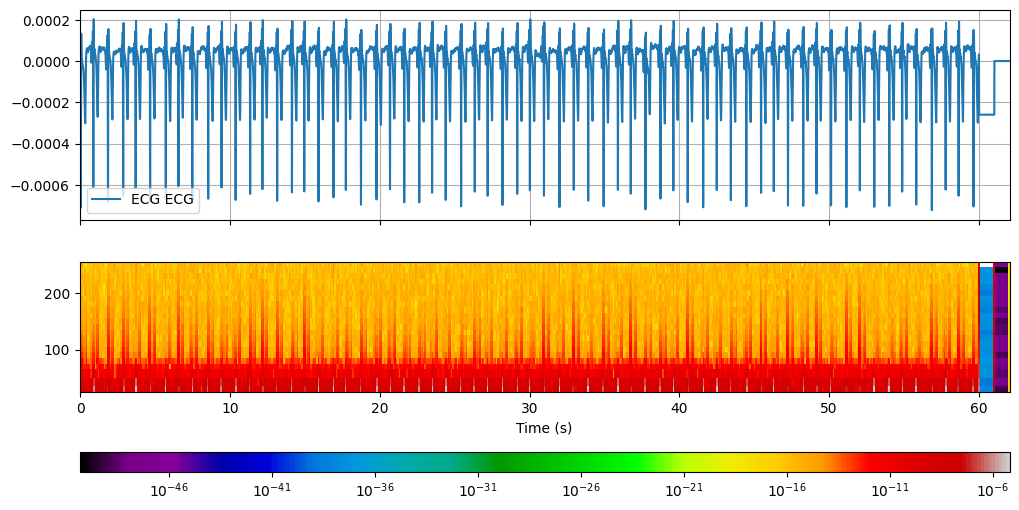

In [82]:
from msa.visualization import plot
subject_id, channel_id, operation_id = 10, 20, 1
aux = X_tensor[subject_id, operation_id, channel_id,:,:] # Subject, Channel, Operation, times, freqs

# Solo conserva filas que NO tengan ningún NaN
aux = aux.T
aux = aux[~np.isnan(aux).any(axis=1)]

fig, ax = plt.subplots(2,1, figsize = (12,6), sharex=True)


file = f"../data/EEG/Subject{subject_id:02d}_{operations[operation_id]}.edf"
data = mne.io.read_raw_edf(file)
raw_data = data.get_data()[:, :]
test_signal = raw_data[:, :].T
time = np.linspace(0, test_signal.shape[0]/500, test_signal.shape[0])
ax[0].plot(time, test_signal[:, channel_id], label=channels[channel_id], alpha=1.0)
ax[0].grid(True)
ax[0].legend()
ax[1].set_xlabel("Time (s)");
xlim = ax[0].get_xlim()

_, _ , mesh = plot.spectrogram(times[:aux.shape[0]], freqs, aux.T, logscale=True, ax=ax[1]);

from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax[1])
cax = divider.append_axes("bottom", size="15%", pad=0.6)
fig.colorbar(mesh, cax=cax, orientation='horizontal')

In [81]:
time.shape, times.shape
times[:aux.shape[0]] # ---> Ojo, no quiero la cantidad de elementos (shape), sino hasta el adecuado. Hay valores negativos, por lo que se descompensa.

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
       2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5])

### Normalization
Tiene sentido normalizar tanto los canales como los sujetos

In [72]:
# Block scaling
print(X_tensor.shape)
X_norm = X_tensor.copy();

# Block scaling: Channels
for i in range(X_tensor.shape[2]):
    aux = X_norm[:, :, i, :, :]
    mu = np.nanmean(aux)
    sigma = np.nanstd(aux)
    X_norm[:, :, i, :, :] = (aux - mu)/sigma

# # Block scaling: Subjects
# for i in range(X_tensor.shape[0]):
#     aux = X_norm[i, :, :, :, :]
#     mu = np.nanmean(aux)
#     sigma = np.nanstd(aux)
#     X_norm[i, :, :, :, :] = (aux - mu)/sigma


n_subjects, n_operations, n_channels, n_freqs, n_times = X_norm.shape

(36, 2, 21, 22, 1881)


### Unfolding

rows: (subject $\times$ operation $\times$ time)

columns: (channel $\times$ freqs)


In [73]:
X_transposed = X_norm.transpose(0, 1, 4, 2, 3)
X_unfold = X_transposed.reshape(n_subjects * n_operations * n_times, n_channels * n_freqs)

repeats = n_operations*n_times
F_subject = np.repeat(subject_ids, repeats)
F_ages = np.repeat(subject_ages, repeats)
F_genders = np.repeat(subject_genders, repeats)
F_rec_years = np.repeat(subject_rec_years, repeats)
F_n_subtractions = np.repeat(subject_n_subtractions, repeats)
F_quality = np.repeat(subject_quality, repeats)
F_operations = np.repeat(operations, n_subjects*n_times)

freqs_label = np.tile(freqs, len(channels))
channels_label = np.repeat(channels, n_freqs)

X_unfold.shape

(135432, 462)

#### Remove NaN rows

In [74]:
idx = ~np.isnan(X_unfold).any(axis=1)

X_unfold = X_unfold[idx]
F_subject = F_subject[idx]
F_ages = F_ages[idx]
F_genders = F_genders[idx]
F_rec_years = F_rec_years[idx]
F_n_subtractions = F_n_subtractions[idx]
F_quality = F_quality[idx]
F_operations = F_operations[idx]

X_unfold.shape

(86832, 462)

### MEDA Visualization

In [83]:
# Save data in .mat format
from scipy.io import savemat

data_dict = {
    'X_unfold': X_unfold,
    'F_subject': np.array(F_subject, dtype=object),
    'F_ages': F_ages,
    'F_genders': np.array(F_genders, dtype=object),
    'F_rec_years': F_rec_years,
    'F_n_subtractions': F_n_subtractions,
    'F_quality': F_quality,
    'F_operations': F_operations,

    'freqs': freqs_label,
    'channels': channels_label
}

savemat("../data/EEG/EEG.mat", data_dict)


### MSPC